<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/fields/09_optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Field 9 · Optimisation · taste project*

# What's the best schedule, route or allocation under a set of rules?

> **In short**
>
> **What's the best schedule, route or allocation under a set of rules?**
>
> Write down the rules (the constraints) and the goal precisely, then search the possible answers cleverly. For huge problems, start with any answer and keep improving it with small changes.

## Where you'll end up

By the end you will have built:

1. **An exam timetable** that satisfies every rule: first with your own backtracking search, then with a professional solver (Google OR-Tools).
2. **A delivery route through 30 stops**, untangled by simulated annealing (below), and compared with simpler methods.
3. **A branch-and-bound search** that finds the guaranteed shortest route for small cases while skipping most of the options.

Running every cell takes about a minute, including installing OR-Tools.

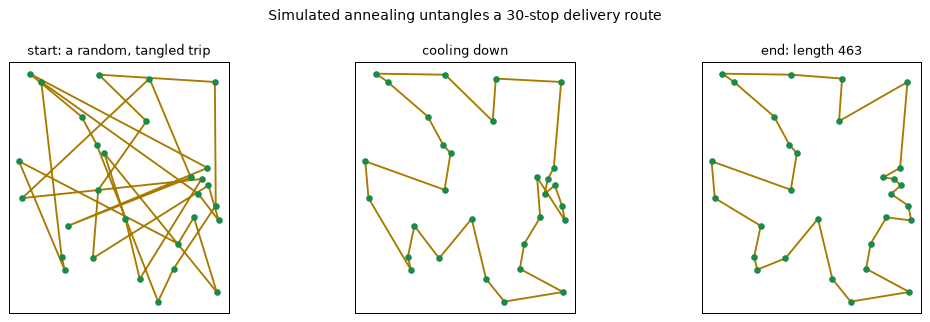

## How to use this notebook

- Run each grey code cell with **Shift + Enter**, top to bottom.
- 🤔 **Predict first** boxes ask you to guess before you run. The answer is one click away.
- 🐍 **Python notes** explain Python as it comes up.
- Exercise solutions are in collapsed cells. In Colab, double-click a solution's title to open it.

In [1]:
%pip install -q ortools   # Google's constraint solver, used in section 3

Note: you may need to restart the kernel to use updated packages.


## 1. The problem: an exam timetable

Ten exams must fit into five time slots. The rules:

- No student can sit two exams at the same time.
- At most three exams can run in the same slot (there are three rooms).
- The maths lecturer is away in slot 0, so maths exams can't go there.

**Which exam goes in which slot?** There are $5^{10}$, about 9.8 million, ways to assign the slots. Most break a rule.

In [2]:
EXAMS = ["Algebra", "Calculus", "Statistics", "Databases", "Networks",
         "Python", "AI", "Ethics", "Graphics", "Security"]
SLOTS = 5
ROOMS = 3
MATHS = {"Algebra", "Calculus", "Statistics"}

# which exams share at least one student (they must not clash)
CLASH = {("Algebra", "Calculus"), ("Algebra", "Statistics"), ("Calculus", "Statistics"), ("Statistics", "AI"),
         ("Databases", "Python"), ("Python", "AI"), ("AI", "Ethics"), ("Networks", "Security"),
         ("Databases", "Security"), ("Graphics", "Python"), ("Calculus", "Graphics"), ("Ethics", "Security"),
         ("Algebra", "AI"), ("Networks", "Python")}
clash = {e: set() for e in EXAMS}
for a, b in CLASH:
    clash[a].add(b); clash[b].add(a)
print("possible assignments:", f"{SLOTS ** len(EXAMS):,}")
print("Python clashes with:", sorted(clash["Python"]))

possible assignments: 9,765,625
Python clashes with: ['AI', 'Databases', 'Graphics', 'Networks']


🐍 **Python notes**
- `{("Algebra", "Calculus"), ...}` is a **set** of pairs. `{e: set() for e in EXAMS}` builds a dict of empty sets, one per exam.
- `clash[a].add(b)` adds to a set; duplicates are ignored automatically.

**What it's called:** each exam is a **variable**; its possible slots are its **domain**; each rule is a **constraint**. A problem like this is a **constraint satisfaction problem**.

## 2. Search with undo: backtracking

Assign exams one at a time. After each choice, check the rules for what's assigned so far.
If an exam has no slot left that works, **undo** the last choice and try its next option.

In [3]:
def ok(exam, slot, plan):
    if exam in MATHS and slot == 0:
        return False
    if sum(1 for s in plan.values() if s == slot) >= ROOMS:
        return False
    return all(plan.get(other) != slot for other in clash[exam])

def backtrack(plan, order, stats):
    if len(plan) == len(order):
        return dict(plan)
    exam = order[len(plan)]
    for slot in range(SLOTS):
        stats["tried"] += 1
        if ok(exam, slot, plan):
            plan[exam] = slot
            result = backtrack(plan, order, stats)
            if result:
                return result
            del plan[exam]                      # undo, try the next slot
    return None

stats = {"tried": 0}
plan = backtrack({}, EXAMS, stats)
print("slot choices tried:", stats["tried"])
for s in range(SLOTS):
    print(f"slot {s}:", [e for e, v in plan.items() if v == s])

slot choices tried: 23
slot 0: ['Databases', 'Networks', 'AI']
slot 1: ['Algebra', 'Python', 'Ethics']
slot 2: ['Calculus', 'Security']
slot 3: ['Statistics', 'Graphics']
slot 4: []


🐍 **Python notes**
- `backtrack` calls itself: **recursion**. Each call handles one exam; returning `None` tells the caller "no luck, try something else".
- `del plan[exam]` removes a key from a dict: the undo step.
- `plan.get(other)` returns `None` if `other` isn't assigned yet, instead of raising an error.

**What it's called:** this is **backtracking**. It skips huge parts of the 9.8 million assignments: once a partial plan breaks a rule, nothing built on it is tried.

### 🤔 Predict first

Backtracking assigns the exams in a fixed order. **Does that order change how many slot choices it tries?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**Yes, when the timetable is tight.** With 5 slots there is plenty of room, so almost any order is quick. With 4 slots, most orders are still quick, but a few try hundreds of choices. Placing the most-clashing exams first avoids those bad cases: problems show up early, when undoing is cheap.

</details>

In [4]:
import random
hardest_first = sorted(EXAMS, key=lambda e: -len(clash[e]) - (2 if e in MATHS else 0))

def tries(order):
    st = {"tried": 0}
    backtrack({}, order, st)
    return st["tried"]

random.seed(1)
for SLOTS in (5, 4):          # the loop changes the global SLOTS that backtrack reads; 4 is a tighter timetable
    counts = sorted(tries(random.sample(EXAMS, len(EXAMS))) for _ in range(200))
    print(f"{SLOTS} slots: 200 random orders tried {counts[0]} to {counts[-1]} choices (middle: {counts[100]}).",
          f"Hardest first: {tries(hardest_first)}.")
SLOTS = 5                     # back to the real problem

5 slots: 200 random orders tried 22 to 27 choices (middle: 23). Hardest first: 26.
4 slots: 200 random orders tried 22 to 345 choices (middle: 23). Hardest first: 26.


🐍 `random.sample(EXAMS, len(EXAMS))` returns the exams in a random order. `sorted(f(x) for x in ...)` collects the results and sorts them, so `counts[0]` is the smallest and `counts[-1]` the largest.

**What it's called:** picking the most constrained variable first is a **variable-ordering heuristic**: a rule of thumb that doesn't change the answer, only how fast you find it.

## 3. The library version: a constraint solver

Real timetables have hundreds of exams. You write the **model** (variables, constraints, goal) and a **solver** does the search, with far better tricks than plain backtracking.
Here is the same model in Google **OR-Tools** CP-SAT, plus a goal: **as few clashing pairs as possible in back-to-back slots**, so students who sit both exams get a break between them.

In [5]:
from ortools.sat.python import cp_model

m = cp_model.CpModel()
slot = {e: m.NewIntVar(0, SLOTS - 1, e) for e in EXAMS}
for a, b in CLASH:
    m.Add(slot[a] != slot[b])                                   # no clashes
for e in MATHS:
    m.Add(slot[e] != 0)                                         # lecturer away in slot 0
for s in range(SLOTS):                                          # at most ROOMS exams per slot
    in_s = []
    for e in EXAMS:
        b = m.NewBoolVar(f"{e}_in_{s}")
        m.Add(slot[e] == s).OnlyEnforceIf(b)
        m.Add(slot[e] != s).OnlyEnforceIf(b.Not())
        in_s.append(b)
    m.Add(sum(in_s) <= ROOMS)

back_to_back = []                                               # goal: avoid neighbouring slots for clashing pairs
for a, b in CLASH:
    gap = m.NewIntVar(0, SLOTS, f"gap_{a}_{b}")
    m.AddAbsEquality(gap, slot[a] - slot[b])
    tight = m.NewBoolVar(f"tight_{a}_{b}")
    m.Add(gap == 1).OnlyEnforceIf(tight)
    m.Add(gap != 1).OnlyEnforceIf(tight.Not())
    back_to_back.append(tight)
m.Minimize(sum(back_to_back))

solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 10
status = solver.Solve(m)
print(solver.StatusName(status), "- back-to-back pairs:", int(solver.ObjectiveValue()))
for s in range(SLOTS):
    print(f"slot {s}:", [e for e in EXAMS if solver.Value(slot[e]) == s])

OPTIMAL - back-to-back pairs: 1
slot 0: ['Python', 'Security']
slot 1: ['Algebra']
slot 2: ['Statistics', 'Ethics', 'Graphics']
slot 3: ['Databases', 'Networks']
slot 4: ['Calculus', 'AI']


**What you see:** a valid timetable that also keeps clashing exams apart where possible. `OPTIMAL` means the solver proved no better timetable exists.

**The same model in MiniZinc.** Monash is a home of the **MiniZinc** modelling language, and FIT5216 is about modelling problems like this one. A MiniZinc model reads almost like the rules in English:

```
int: SLOTS = 5;
enum EXAM = {Algebra, Calculus, Statistics, Databases, Networks, Python, AI, Ethics, Graphics, Security};
array[EXAM] of var 0..SLOTS-1: slot;

constraint slot[Algebra] != slot[Calculus];          % ... one line per clashing pair
constraint forall(e in {Algebra, Calculus, Statistics}) (slot[e] != 0);
constraint forall(s in 0..SLOTS-1) (sum(e in EXAM) (slot[e] = s) <= 3);

solve satisfy;
```

(Running MiniZinc needs its own install; the official tutorial is linked at the end.)

## 4. A route through 30 stops

A courier visits 30 stops and returns. **Which order is shortest?**

### 🤔 Predict first

**How many different round trips are there through 30 stops?** (Fix the start; a trip and its reverse count as one.)

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

$29!/2 \approx 4.4 \times 10^{30}$. Checking a billion per second would take about $10^{14}$ years. Run the next cell for the exact count.

</details>

In [6]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(4)
CITIES = rng.uniform(0, 100, size=(30, 2))

def tour_length(tour, pts=CITIES):
    p = pts[tour]
    return float(np.linalg.norm(p - np.roll(p, -1, axis=0), axis=1).sum())

def anneal(pts=CITIES, steps=40000, t_start=30.0, t_end=0.05, seed=0, record_every=1000):
    r = np.random.default_rng(seed)
    tour = r.permutation(len(pts))
    best = cur = tour_length(tour, pts)
    best_tour, history, frames = tour.copy(), [], []
    for k in range(steps):
        T = t_start * (t_end / t_start) ** (k / steps)          # cool down smoothly
        i, j = sorted(r.choice(len(pts), 2, replace=False))
        new = tour.copy()
        new[i:j + 1] = new[i:j + 1][::-1]                       # reverse one section of the trip
        delta = tour_length(new, pts) - cur
        if delta < 0 or r.random() < np.exp(-delta / T):        # always accept better; sometimes accept worse
            tour, cur = new, cur + delta
            if cur < best:
                best, best_tour = cur, tour.copy()
        if k % record_every == 0:
            history.append((k, cur, T))
            frames.append(tour.copy())
    return best_tour, best, history, frames

import math
print(f"round trips through 30 stops: {math.factorial(29) // 2:,}")

round trips through 30 stops: 4,420,880,996,869,850,977,271,808,000,000


🐍 `np.roll(p, -1, axis=0)` shifts the rows up by one, wrapping the first to the end; subtracting it from `p` gives the step from each stop to the next, including the step home.

**What it's called:** this is the **travelling salesperson problem** (TSP). It is **NP-hard**: no known method finds the guaranteed best trip in time that grows only polynomially with the number of stops.

### A quick answer: always go to the nearest stop

In [7]:
def nearest_neighbour(pts=CITIES, start=0):
    left = set(range(len(pts))) - {start}
    tour = [start]
    while left:
        here = pts[tour[-1]]
        nxt = min(left, key=lambda j: np.linalg.norm(pts[j] - here))
        tour.append(nxt); left.remove(nxt)
    return np.array(tour)

greedy = nearest_neighbour()
print("nearest-stop-next trip length:", round(tour_length(greedy)))

nearest-stop-next trip length: 564


**What it's called:** taking the best-looking step now, with no planning ahead, is a **greedy** heuristic. It is fast, but the last few steps often have to cross the map back to the start.

### Improve it with small changes: simulated annealing

Start from a random trip. Repeatedly pick a section of the trip and reverse it. Keep the change if the trip gets shorter.
**Also keep some changes that make it longer**, with probability $e^{-\Delta/T}$, where $\Delta$ is how much longer and $T$ (the **temperature**) shrinks over time.

In [8]:
import time
t0 = time.time()
best_tour, best, history, frames = anneal()
print(f"annealing: length {best:.0f} in {time.time() - t0:.1f}s   (greedy: {tour_length(greedy):.0f})")

from matplotlib import animation
from IPython.display import HTML
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ks, lens, temps = zip(*history)
def frame(i):
    ax.clear(); ax2.clear()
    p = CITIES[np.append(frames[i], frames[i][0])]
    ax.plot(p[:, 0], p[:, 1], color="#a87b00"); ax.scatter(CITIES[:, 0], CITIES[:, 1], color="#188a4a", zorder=3, s=15)
    ax.set_title(f"step {ks[i]:,}: length {lens[i]:.0f}, temperature {temps[i]:.2f}"); ax.set_xticks([]); ax.set_yticks([])
    ax2.plot(ks[:i + 1], lens[:i + 1], color="#a87b00"); ax2.set_xlim(0, ks[-1]); ax2.set_ylim(min(lens) * 0.95, max(lens) * 1.05)
    ax2.set_xlabel("step"); ax2.set_ylabel("trip length")
anim = animation.FuncAnimation(fig, frame, frames=len(frames), interval=150)
plt.close(fig)
HTML(anim.to_jshtml())

annealing: length 463 in 1.1s   (greedy: 564)


**What you see:** early on (high temperature), the length jumps up and down: many worse trips are accepted. As it cools, it settles and crossings disappear.

**Why accept worse trips?** A search that only accepts improvements gets stuck: sometimes no single reversal helps, though a better trip exists a few changes away. Test that:

In [9]:
greedy_only = [anneal(t_start=1e-6, t_end=1e-9, seed=s, steps=20000)[1] for s in range(5)]
annealed = [anneal(seed=s, steps=20000)[1] for s in range(5)]
print("only accept improvements:", [round(x) for x in greedy_only])
print("simulated annealing:     ", [round(x) for x in annealed])

only accept improvements: [465, 499, 490, 472, 463]
simulated annealing:      [467, 462, 462, 464, 462]


**What it's called:** improving one answer by small changes is **local search**. A trip no single change can improve is a **local optimum**. Accepting worse moves with a shrinking probability is **simulated annealing**.

## 5. Guaranteed best, without checking everything: branch and bound

For small cases you can find the guaranteed shortest trip. Build trips stop by stop.
**If a half-built trip is already longer than the best complete trip found so far, abandon it**: nothing built on it can win.

In [10]:
def branch_and_bound(pts):
    n = len(pts)
    D = np.linalg.norm(pts[:, None] - pts[None, :], axis=2)
    best = [nearest_neighbour(pts).tolist(), tour_length(nearest_neighbour(pts), pts)]   # a first answer to beat
    counted = {"partial trips": 0}
    def extend(tour, length, left):
        counted["partial trips"] += 1
        if length >= best[1]:
            return                                    # bound: can't beat the best so far
        if not left:
            total = length + D[tour[-1], tour[0]]
            if total < best[1]:
                best[0], best[1] = tour[:], total
            return
        for j in sorted(left, key=lambda j: D[tour[-1], j]):      # branch: try near stops first
            tour.append(j)
            extend(tour, length + D[tour[-2], j], left - {j})
            tour.pop()
    extend([0], 0.0, set(range(1, n)))
    return best, counted["partial trips"]

small = CITIES[:10]
t0 = time.time()
(best_tour10, best10), explored = branch_and_bound(small)
all_partial = sum(math.factorial(9) // math.factorial(9 - k) for k in range(10))
print(f"10 stops: shortest length {best10:.1f}, found in {time.time() - t0:.1f}s")
print(f"partial trips explored: {explored:,} out of {all_partial:,} possible")

10 stops: shortest length 278.7, found in 0.2s
partial trips explored: 195,906 out of 986,410 possible


**What it's called:** splitting the problem into choices is **branching**; abandoning a branch that can't beat the best so far is **bounding**. Together: **branch and bound**.
It still explodes for large inputs (that's NP-hardness), but it pushes the limit far beyond checking everything.

## Practice

Try each one before opening its solution.

### Exercise 1

By hand: **how many round trips are there through 6 stops** (same start; a trip and its reverse count as one)?

<details><summary><b>Show the answer to exercise 1</b></summary>

Fix the start; the other 5 can go in $5! = 120$ orders; halve for direction: **60**.

</details>

### Exercise 2

Add a rule to the timetable: **Python must come before AI** (an earlier slot). Add it to the backtracking version and to the OR-Tools model, and print both timetables.

In [11]:
# your code here

In [12]:
#@title Solution to exercise 2 (double-click to show)
def ok2(exam, s, plan):
    if not ok(exam, s, plan):
        return False
    if exam == "AI" and "Python" in plan and plan["Python"] >= s:
        return False
    if exam == "Python" and "AI" in plan and plan["AI"] <= s:
        return False
    return True

def backtrack2(plan, order):
    if len(plan) == len(order):
        return dict(plan)
    exam = order[len(plan)]
    for s in range(SLOTS):
        if ok2(exam, s, plan):
            plan[exam] = s
            r = backtrack2(plan, order)
            if r:
                return r
            del plan[exam]
    return None

p2 = backtrack2({}, hardest_first)
print("backtracking: Python", p2["Python"], "AI", p2["AI"])
m.Add(slot["Python"] < slot["AI"])
solver.Solve(m)
print("OR-Tools:     Python", solver.Value(slot["Python"]), "AI", solver.Value(slot["AI"]))

backtracking: Python 0 AI 2


OR-Tools:     Python 0 AI 4


### Exercise 3

Simulated annealing has two settings: the starting temperature and the number of steps. **Find settings that beat the default trip length for this map**, and say why they help.

In [13]:
# your experiment here

In [14]:
#@title Solution to exercise 3 (double-click to show)
for t_start, steps in [(30, 40000), (10, 80000), (60, 80000), (5, 20000)]:
    lengths = [anneal(t_start=t_start, steps=steps, seed=s)[1] for s in range(3)]
    print(f"start temperature {t_start:3d}, {steps:6,} steps: {np.round(lengths)}")
# More steps means slower cooling: more time near each temperature, so fewer bad tangles get locked in.
# Too low a start temperature behaves like plain local search; too high wastes steps wandering.

start temperature  30, 40,000 steps: [463. 463. 480.]


start temperature  10, 80,000 steps: [461. 473. 461.]


start temperature  60, 80,000 steps: [463. 463. 461.]


start temperature   5, 20,000 steps: [463. 485. 463.]


## Recognition cues

- When you see **"find an assignment that satisfies all these rules"** in a problem, think **constraint modelling: variables, domains, constraints, then a solver**.
- When you see **"try, and undo when a choice breaks a rule"** in a problem, think **backtracking**.
- When you see **the number of options grows like n!** in a problem, think **don't check them all: heuristics, local search, or branch and bound**.
- When you see **local search keeps getting stuck** in a problem, think **accept some worse moves (simulated annealing)**.

## Try changing this

1. **A harder timetable.** Set `SLOTS = 3`. Does a valid timetable still exist? Can you tell before running it?
2. **Clustered stops.** Put the 30 stops in three tight groups. Which method does best now: greedy or annealing?
3. **Bigger branch and bound.** Try 12 stops. How fast does the explored count grow?

## Open research questions

People are working on these right now:

- Can learned models help solvers find answers faster?
- How do we optimise when the rules keep changing?

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **Optimisation** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.

## Go deeper

- The official MiniZinc tutorial: https://docs.minizinc.dev/en/stable/part_2_tutorial.html
- At Monash: FIT5216 Modelling discrete optimisation problems. Monash is a home of the MiniZinc modelling language.